# 04. Simulation

## 4-1. 시뮬레이션 기본 세팅

In [ ]:
repair_compare_df['caseID'] = repair_compare_df['caseID'].astype(int)
step_df['caseID'] = step_df['caseID'].astype(int)

In [ ]:
dup_cols = (
    repair_compare_df.columns
    .intersection(add_df.columns)
    .drop("caseID")
)

In [210]:
simulation_df = add_df.merge(
    repair_compare_df.drop(columns=dup_cols),
    on="caseID",
    how="left"
)
simulation_df

,caseID,EstimatedRepairTime,RepairType,RepairInternally,RepairCode,first_repair_start,last_repair_complete,actual_repair_time_minutes,actual_repair_time_hr,repair_time_diff,...,survey_duration,internrepair_duration,immediaterepair_duration,externrepair_duration,first_repair_type,last_repair_type,time_bucket,expected_repair_type,rule_match,repair_time_diff_days
0,1,240,E,TRUE,1.0,1970-01-17 04:36:00,1970-01-17 08:12:00,216.0,3.600000,-24.0,...,23.0,216.0,NaN,NaN,InternRepair,InternRepair,<=240,InternRepair,True,-0.016667
1,2,120,P,TRUE,1.0,1970-01-12 04:57:00,1970-01-12 08:57:00,240.0,4.000000,120.0,...,38.0,NaN,120.0,120.0,ImmediateRepair,ExternRepair,<=120,ImmediateRepair,True,0.083333
2,3,220,E,TRUE,2.0,1970-01-06 19:50:00,1970-01-06 23:30:00,220.0,3.666667,0.0,...,16.0,220.0,NaN,NaN,InternRepair,InternRepair,<=240,InternRepair,True,0.000000
3,4,120,P,TRUE,1.0,1970-01-04 17:42:00,1970-01-04 19:42:00,120.0,2.000000,0.0,...,39.0,NaN,120.0,NaN,ImmediateRepair,ImmediateRepair,<=120,ImmediateRepair,True,0.000000
4,5,120,P,TRUE,1.0,1970-01-09 23:22:00,1970-01-10 01:10:00,108.0,1.800000,-12.0,...,47.0,NaN,108.0,NaN,ImmediateRepair,ImmediateRepair,<=120,ImmediateRepair,True,-0.008333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922,996,220,E,TRUE,2.0,1970-01-02 08:49:00,1970-01-02 12:29:00,220.0,3.666667,0.0,...,26.0,220.0,NaN,NaN,InternRepair,InternRepair,<=240,InternRepair,True,0.000000
923,997,240,E,TRUE,1.0,1970-01-14 15:55:00,1970-01-14 20:19:00,264.0,4.400000,24.0,...,34.0,264.0,NaN,NaN,InternRepair,InternRepair,<=240,InternRepair,True,0.016667
924,998,220,E,TRUE,2.0,1970-01-19 06:54:00,1970-01-19 10:34:00,220.0,3.666667,0.0,...,28.0,220.0,NaN,NaN,InternRepair,InternRepair,<=240,InternRepair,True,0.000000
925,999,480,B,FALSE,4.0,1970-01-07 05:11:00,1970-01-07 12:23:00,432.0,7.200000,-48.0,...,21.0,NaN,NaN,432.0,ExternRepair,ExternRepair,360+,ExternRepair,True,-0.033333


In [211]:
simulation_df["repair_type"].value_counts()

repair_type
Internal    795
External    132
Name: count, dtype: int64

## 4-2. AS-IS 데이터/지표 구성

In [212]:
simulation_df = simulation_df.merge(
    step_df[["caseID", "InformClientSurvey > Survey"]],
    on="caseID",
    how="left"
)

In [214]:
# ============================================================
# 0. 원칙: "접수(Survey) 시점에 이미 확정되거나 합리적으로 추정 가능한 정보"만 사용
#    → repair_count(재수리 횟수), ExternRepair 가산비처럼
#      "수리가 진행되어야 확정되는 정보"는 제외
#    → 대신 기본 공임비, 제품가 기반 부품비 추정, 진단 단계 심각도는
#      실제 수리비 산정표처럼 접수 시점에도 어느 정도 추정 가능하므로 포함
# ============================================================

# ------------------------------------------------------------
# 1. Severity — 접수 시점 정보(product_category)만으로 배정
# ------------------------------------------------------------
def assign_severity_pre(row, rng):
    if row["product_category"] in ["대형가전", "정밀/의료기기"]:
        p = {"low": 0.2, "medium": 0.3, "high": 0.5}
    else:
        p = {"low": 0.5, "medium": 0.3, "high": 0.2}
    return rng.choice(list(p.keys()), p=list(p.values()))

rng = np.random.default_rng(42)
simulation_df["failure_severity_pre"] = simulation_df.apply(lambda r: assign_severity_pre(r, rng), axis=1)

# ------------------------------------------------------------
# 2. Estimated Repair Cost — 접수 시점 추정 가능한 항목만으로 재구성
#    (재수리 횟수, "외주 여부"는 넣어도 되고, "repair_sequence 기반 가산비"만 제외 - 사후 확정 정보이므로)
# ------------------------------------------------------------
def calculate_estimated_cost(row, rng):
    base_cost = 30000

    price_rate_map = {
        "IT/소형가전": rng.uniform(0.10, 0.15),
        "생활가전": rng.uniform(0.07, 0.12),
        "대형가전": rng.uniform(0.05, 0.10),
        "정밀/의료기기": rng.uniform(0.04, 0.08),
    }
    price_cost = row["product_price"] * price_rate_map.get(row["product_category"], 0.08)

    severity_cost_map = {
        "low": rng.uniform(10000, 30000),
        "medium": rng.uniform(30000, 60000),
        "high": rng.uniform(60000, 120000),
    }
    severity_cost = severity_cost_map.get(row["failure_severity_pre"], 30000)

    # 외주 가산비 — repair_sequence(사후) 대신 RepairInternally(접수 시점 확정값) 사용
    extern_cost = 0
    if row["RepairInternally"] == "FALSE":  # 실제 원본 컬럼의 값 표기에 맞게 조정
        base = 100000 if row["product_category"] in ["대형가전", "정밀/의료기기"] else 60000
        extern_cost = rng.uniform(base, base + 50000)

    noise = rng.uniform(-10000, 10000)
    return int(max(15000, base_cost + price_cost + severity_cost + extern_cost + noise))

rng_cost = np.random.default_rng(43)
simulation_df["estimated_repair_cost"] = simulation_df.apply(lambda r: calculate_estimated_cost(r, rng_cost), axis=1)


# ------------------------------------------------------------
# 3. Operational Risk — severity_score 스케일링 (0.2~1.0, starvation 방지)
# ------------------------------------------------------------
severity_map = {"low": 1, "medium": 2, "high": 3}
simulation_df["severity_score"] = simulation_df["failure_severity_pre"].map(severity_map)

scaler_risk = MinMaxScaler(feature_range=(0.2, 1.0))
# Risk의 최소값을 0.2로 설정하여 낮은 Severity Case도 Priority Score 산정 대상에서 완전히 배제되지 않도록 설계
simulation_df["operational_risk_norm"] = scaler_risk.fit_transform(simulation_df[["severity_score"]])


# ------------------------------------------------------------
# 4. Business Value — estimated_repair_cost 기준으로 정규화
# ------------------------------------------------------------
scaler_business = MinMaxScaler()
simulation_df["business_norm"] = scaler_business.fit_transform(simulation_df[["estimated_repair_cost"]])


# ------------------------------------------------------------
# 5. Priority Score = Business Value × Operational Risk
# ------------------------------------------------------------
simulation_df["priority_score"] = simulation_df["business_norm"] * simulation_df["operational_risk_norm"]


# ------------------------------------------------------------
# 6. 검증
# ------------------------------------------------------------
simulation_df["sla_breach"] = (simulation_df["case_lead_time_min"] > 10000).astype(int)

print("priority_score - sla_breach 상관관계 (낮을수록 leak 없음):")
print(simulation_df[["priority_score", "sla_breach"]].corr())

print(f"\npriority_score == 0인 케이스 비율: {(simulation_df['priority_score']==0).mean()*100:.1f}%")
print(simulation_df["priority_score"].describe())

print(f"\nestimated_repair_cost vs 실제 repair_cost 비교 (참고용):")
print(simulation_df[["estimated_repair_cost", "repair_cost"]].describe())


priority_score - sla_breach 상관관계 (낮을수록 leak 없음):
                priority_score  sla_breach
priority_score        1.000000    0.011744
sla_breach            0.011744    1.000000

priority_score == 0인 케이스 비율: 0.1%
count    927.000000
mean       0.109424
std        0.170773
min        0.000000
25%        0.004070
50%        0.022067
75%        0.170105
max        1.000000
Name: priority_score, dtype: float64

estimated_repair_cost vs 실제 repair_cost 비교 (참고용):
       estimated_repair_cost   repair_cost
count           9.270000e+02  9.270000e+02
mean            2.513844e+05  2.911116e+05
std             2.650769e+05  2.530406e+05
min             4.499700e+04  5.907400e+04
25%             7.805250e+04  1.305320e+05
50%             1.485880e+05  2.005950e+05
75%             3.244375e+05  3.463510e+05
max             1.669349e+06  1.651187e+06


In [215]:
print(f"priority_score == 0인 케이스 비율: {(simulation_df['priority_score']==0).mean()*100:.1f}%")
print(f"failure_severity_pre 분포:\n{simulation_df['failure_severity_pre'].value_counts(normalize=True)}")

priority_score == 0인 케이스 비율: 0.1%
failure_severity_pre 분포:
failure_severity_pre
low       0.495146
high      0.317152
medium    0.187702
Name: proportion, dtype: float64


In [216]:
# true_waiting_time
REPAIR_TASKS = ["InternRepair", "ImmediateRepair", "ExternRepair", "RepairReady"]

is_repair_internal_gap = (
    flow_df["taskID"].isin(REPAIR_TASKS) & flow_df["next_taskID"].isin(REPAIR_TASKS)
)
flow_df["event_gap_min_pure"] = np.where(is_repair_internal_gap, np.nan, flow_df["event_gap_min"])

true_waiting_df_pure = (
    flow_df[flow_df["event_gap_min_pure"].notna()]
    .groupby("caseID", as_index=False)
    .agg(true_waiting_time_pure_hr=("event_gap_min_pure", lambda x: x.sum() / 60))
)

simulation_df = simulation_df.merge(true_waiting_df_pure, on="caseID", how="left")
simulation_df["true_waiting_time_pure_hr"] = simulation_df["true_waiting_time_pure_hr"].fillna(0)

simulation_df["other_time_pure_hr"] = (
    simulation_df["case_lead_time_hr"]
    - simulation_df["actual_repair_time_hr"]
    - simulation_df["true_waiting_time_pure_hr"]
)

# 검증 - 음수가 없어야 정상
print("음수 개수:", (simulation_df["other_time_pure_hr"] < 0).sum())
print(simulation_df["other_time_pure_hr"].describe())


음수 개수: 0
count    927.000000
mean       2.758288
std        4.674762
min        0.333333
25%        0.733333
50%        0.916667
75%        1.175000
max       37.150000
Name: other_time_pure_hr, dtype: float64


In [220]:
def calc_locked_capital(df):
    return (
        df["repair_cost"] * (df["case_lead_time_hr"] / 24)
    ).sum()

In [221]:
def get_metrics(df):
    vip_threshold = df["priority_score"].quantile(0.8)
    vip_mask = df["priority_score"] >= vip_threshold

    return {
        "lead_time": df["case_lead_time_hr"].mean(),
        "vip_lead_time": df.loc[vip_mask, "case_lead_time_hr"].mean(),
        "bottleneck": df["InformClientSurvey > Survey"].mean() / 60,   # 핵심 병목 구간(원본, 분→시간)
        "total_waiting": df["true_waiting_time_pure_hr"].mean(),        # 전체 대기시간(모든 구간 합)
        "capital": calc_locked_capital(df),
    }

In [222]:
# 1. 기본 설정

RANDOM_SEED = 42
N_SIMULATIONS = 1000
IMPROVEMENT_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
VIP_QUANTILE = 0.8

# capacity=3은 실측 기준(현실), capacity=5는 안정화 지점(대안 시나리오)
CAPACITY_SCENARIOS = [3, 5]

np.random.seed(RANDOM_SEED)

In [223]:
# 2. 데이터 준비
df = simulation_df.copy()

# 필요한 컬럼 확인
required_cols = [
    "caseID",
    "case_start",
    "case_lead_time_hr",
    "repair_cost",
    "priority_score",
    "InformClientSurvey > Survey",
    "survey_duration" # 분
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"다음 컬럼이 simulation_df에 없습니다: {missing_cols}")


# 결측 제거
df = df.dropna(
    subset=[
    "case_start",
    "case_lead_time_hr",
    "repair_cost",
    "priority_score",
    "InformClientSurvey > Survey",
    "survey_duration"
    ]
).copy()

In [226]:
df["survey_duration_hr"] = df["survey_duration"] / 60

In [224]:
# 3. VIP 정의
priority_threshold = df["priority_score"].quantile(VIP_QUANTILE)

df["vip_segment"] = np.where(df["priority_score"] >= priority_threshold, "VIP", "Normal")

print("VIP threshold:", priority_threshold)
print(df["vip_segment"].value_counts())

VIP threshold: 0.21176592265715816
vip_segment
Normal    741
VIP       186
Name: count, dtype: int64


### Priority / Capacity 검증 - 가동률 확인

In [228]:
# 개선안1 ~ 3 공통으로 사용하는 초기 Capacity를 만드는 부분
# Survey 담당자 동시 처리 용량(capacity) 데이터 기반 추정
def estimate_concurrency(start_col, end_col, data):
    """Survey_start ~ Survey_end 구간의 실제 동시 처리 건수(concurrency)를 sweep-line으로 추정"""
    events = []
    for _, row in data.dropna(subset = [start_col, end_col]).iterrows():
        events.append((row[start_col], 1))
        events.append((row[end_col], -1))
    events.sort(key = lambda x: x[0])

    concurrent = 0
    max_concurrent = 0
    concurrency_trace = []
    for _, delta in events:
        concurrent += delta
        max_concurrent = max(max_concurrent, concurrent)
        concurrency_trace.append(concurrent)

    return max_concurrent, np.percentile(concurrency_trace, 75)

if "Survey_start" in df.columns and "Survey_end" in df.columns:
    max_c, p75_c = estimate_concurrency("Survey_start", "Survey_end", df)
    print(f"실측 동시 처리 최댓값: {max_c}, 75백분위: {p75_c:.1f}")
    SURVEY_CAPACITY = max(1, int(round(p75_c)))
else:
    SURVEY_CAPACITY = 11 # fallback

print(f"사용할 SURVEY_CAPACITY: {SURVEY_CAPACITY}")

실측 동시 처리 최댓값: 7, 75백분위: 3.0
사용할 SURVEY_CAPACITY: 3


In [230]:
# Survey Queue에 들어오기 전후의 고정 구간 분리
df["post_survey_hr"] = (
    df["case_lead_time_hr"] - (df["InformClientSurvey > Survey"] / 60) - df["survey_duration_hr"]
)

In [232]:
# Survey Queue 도착 시각
df_sorted = df.sort_values("InformClientSurvey_end").reset_index(drop=True)
df_sorted["arrival_hr"] = (
    df_sorted["InformClientSurvey_end"] - df_sorted["InformClientSurvey_end"].min()
).dt.total_seconds() / 3600

OBSERVATION_PERIOD_HR = df_sorted["arrival_hr"].max() # 첫 케이스가 InformClientSurvey_end를 찍은 시점부터 마지막 케이스가 찍은 시점까지의 전체 시간 간격
print(f"관측 기간: {OBSERVATION_PERIOD_HR:.1f} hr, 케이스 수: {len(df_sorted)}")

base_records = df_sorted.to_dict("records")
arrival_values = df_sorted["arrival_hr"].values

관측 기간: 183.2 hr, 케이스 수: 927


In [234]:
print(df["survey_duration_hr"].describe())
print(df["survey_duration_hr"].sum())  # 전체 필요한 총 작업시간

utilization = df["survey_duration_hr"].sum() / (SURVEY_CAPACITY * OBSERVATION_PERIOD_HR)
print(f"이론적 가동률(utilization): {utilization:.2f}")

count    927.000000
mean       0.675207
std        0.205839
min        0.250000
25%        0.533333
50%        0.683333
75%        0.850000
max        1.000000
Name: survey_duration_hr, dtype: float64
625.9166666666667
이론적 가동률(utilization): 1.14


In [235]:
N_CASES = 1000
OBSERVATION_PERIOD_HR = 183.2
AVG_WAIT_HR = 76.76

arrival_rate_per_hr = N_CASES / OBSERVATION_PERIOD_HR
theoretical_queue_length = arrival_rate_per_hr * AVG_WAIT_HR

print(f"도착률: {arrival_rate_per_hr:.2f}건/시간")
print(f"이론적 평균 큐 길이: {theoretical_queue_length:.0f}명")

도착률: 5.46건/시간
이론적 평균 큐 길이: 419명


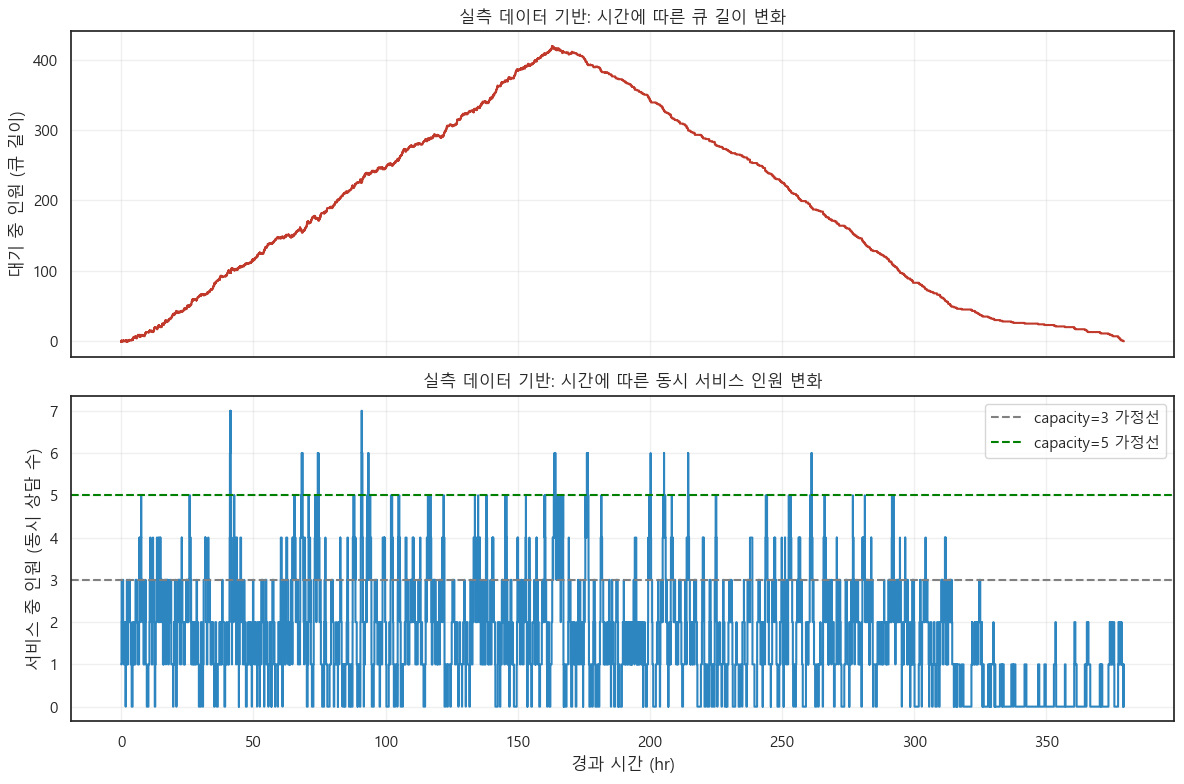

전반부 평균 큐 길이: 217.89명
후반부 평균 큐 길이: 184.46명
관측 기간 내 최대 큐 길이: 419명
관측 기간 내 최대 동시 서비스 인원: 7명


In [236]:
# 대기 종료 시점(=Survey_start, 서비스 시작)의 큐에 몇 명이나 밀려있었는지 확인
# "대기 중이던 사람"과 "서비스 중이던 사람"을 같은 시간축에 겹쳐보기
# 실측 데이터 기반 "큐 길이(대기 중)" vs "서비스 중 인원" 추적

data = df.dropna(subset=["InformClientSurvey_end", "Survey_start", "Survey_end"]).copy()

events = []
for _, row in data.iterrows():
    events.append((row["InformClientSurvey_end"], "arrive"))       # 큐 진입 (대기 시작)
    events.append((row["Survey_start"], "start_service"))          # 큐 이탈 + 서비스 시작
    events.append((row["Survey_end"], "end_service"))              # 서비스 종료

events_df = pd.DataFrame(events, columns=["time", "event"]).sort_values("time").reset_index(drop=True)

queue_len = 0      # 대기 중(큐에 서 있는) 인원
service_len = 0    # 서비스 중(상담 진행 중) 인원

trace = []
for _, row in events_df.iterrows():
    if row["event"] == "arrive":
        queue_len += 1
    elif row["event"] == "start_service":
        queue_len -= 1
        service_len += 1
    elif row["event"] == "end_service":
        service_len -= 1

    trace.append({
        "time": row["time"],
        "event": row["event"],
        "queue_len": queue_len,
        "service_len": service_len,
    })

trace_df = pd.DataFrame(trace)

# 시간(hr) 축으로 변환 (관측 시작 시점 기준)
t0 = trace_df["time"].min()
trace_df["hr"] = (trace_df["time"] - t0).dt.total_seconds() / 3600

# 큐 길이와 서비스 중 인원을 같이 확인
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].step(trace_df["hr"], trace_df["queue_len"], where="post", color="#C0392B")
axes[0].set_ylabel("대기 중 인원 (큐 길이)")
axes[0].set_title("실측 데이터 기반: 시간에 따른 큐 길이 변화")
axes[0].grid(alpha=0.3)

axes[1].step(trace_df["hr"], trace_df["service_len"], where="post", color="#2E86C1")
axes[1].axhline(3, color="gray", linestyle="--", label="capacity=3 가정선")
axes[1].axhline(5, color="green", linestyle="--", label="capacity=5 가정선")
axes[1].set_ylabel("서비스 중 인원 (동시 상담 수)")
axes[1].set_xlabel("경과 시간 (hr)")
axes[1].set_title("실측 데이터 기반: 시간에 따른 동시 서비스 인원 변화")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 큐 길이가 시간이 갈수록 우상향(누적)하는지 확인
first_half = trace_df[trace_df["hr"] <= trace_df["hr"].max() / 2]["queue_len"]
second_half = trace_df[trace_df["hr"] > trace_df["hr"].max() / 2]["queue_len"]

print(f"전반부 평균 큐 길이: {first_half.mean():.2f}명")
print(f"후반부 평균 큐 길이: {second_half.mean():.2f}명")
print(f"관측 기간 내 최대 큐 길이: {trace_df['queue_len'].max()}명")
print(f"관측 기간 내 최대 동시 서비스 인원: {trace_df['service_len'].max()}명")

In [237]:
# 도착 시각(arrival) 기준으로 절반을 나눠서, 그 도착자가 "도착한 순간"의 큐 길이 확인
arrival_events = trace_df[trace_df["event"] == "arrive"].copy()
arrival_events["hr"] = arrival_events["hr"]  # 이미 계산되어 있음

median_arrival_hr = arrival_events["hr"].median()

first_half_arrivals = arrival_events[arrival_events["hr"] <= median_arrival_hr]
second_half_arrivals = arrival_events[arrival_events["hr"] > median_arrival_hr]

print(f"전반부 도착자가 도착한 순간의 평균 큐 길이: {first_half_arrivals['queue_len'].mean():.2f}명")
print(f"후반부 도착자가 도착한 순간의 평균 큐 길이: {second_half_arrivals['queue_len'].mean():.2f}명")

전반부 도착자가 도착한 순간의 평균 큐 길이: 101.78명
후반부 도착자가 도착한 순간의 평균 큐 길이: 317.54명


In [238]:
print("\n===== 가동률 진단 =====")
capacities = [3, 4, 5, 7, 11]
total_work = df["survey_duration_hr"].sum()

utilization_df = pd.DataFrame({
    "capacity": capacities,
    "total_work_hr": total_work,
    "observation_period_hr": OBSERVATION_PERIOD_HR
})

utilization_df["utilization"] = (
    utilization_df["total_work_hr"]
    / (
        utilization_df["capacity"]
        * utilization_df["observation_period_hr"]
    )
)

utilization_df["status"] = np.where(
    utilization_df["utilization"] > 1,
    "불안정(과부하)",
    "안정"
)

utilization_df


===== 가동률 진단 =====


,capacity,total_work_hr,observation_period_hr,utilization,status
0,3,625.916667,183.2,1.138859,불안정(과부하)
1,4,625.916667,183.2,0.854144,안정
2,5,625.916667,183.2,0.683315,안정
3,7,625.916667,183.2,0.488082,안정
4,11,625.916667,183.2,0.310598,안정


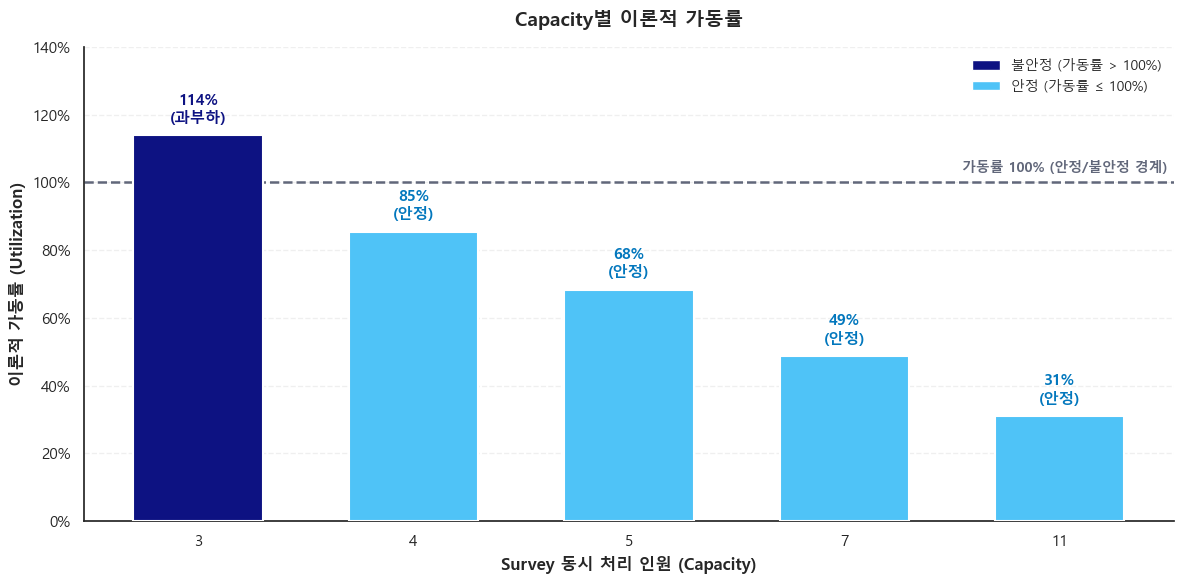

In [239]:
# 데이터
capacities = utilization_df["capacity"]
utilizations = utilization_df["utilization"]

# 안정 / 불안정 여부
is_stable = [u <= 1.0 for u in utilizations]

# 색상
COLOR_UNSTABLE = "#0D1282"   # 과부하
COLOR_STABLE = "#4FC3F7"     # 안정
COLOR_LINE = "#61677A"       # 기준선

bar_colors = [
    COLOR_UNSTABLE if not stable else COLOR_STABLE
    for stable in is_stable
]

# Figure & Axes
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor="white")

# Capacity별 가동률
bars = ax1.bar(
    [str(c) for c in capacities],
    utilizations,
    color=bar_colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# 100% 기준선
ax1.axhline(1.0, color=COLOR_LINE, linestyle="--", linewidth=1.8,  zorder=2)

ax1.text(
    len(capacities) - 0.5,
    1.03,
    "가동률 100% (안정/불안정 경계)",
    color=COLOR_LINE,
    fontsize=10,
    fontweight="bold",
    ha="right"
)

# 막대 위 수치
for bar, util, stable in zip(bars, utilizations, is_stable):

    label = f"{util * 100:.0f}%"
    status = "안정" if stable else "과부하"

    ax1.annotate(
        f"{label}\n({status})",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=COLOR_UNSTABLE if not stable else "#0277BD"
    )

# Y축
ax1.set_ylim(0, 1.4)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax1.set_xlabel("Survey 동시 처리 인원 (Capacity)", fontsize=12, fontweight="bold")

ax1.set_ylabel( "이론적 가동률 (Utilization)", fontsize=12, fontweight="bold")

# 제목
ax1.set_title( "Capacity별 이론적 가동률", fontsize=14, fontweight="bold", pad=15)

# Grid
ax1.grid( axis="y", linestyle="--", alpha=0.3, zorder=0)

# 테두리 제거
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# 범례
legend_elements = [
    Patch(
        facecolor=COLOR_UNSTABLE,
        label="불안정 (가동률 > 100%)"
    ),
    Patch(
        facecolor=COLOR_STABLE,
        label="안정 (가동률 ≤ 100%)"
    )
]

ax1.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "utilization_littles_law.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

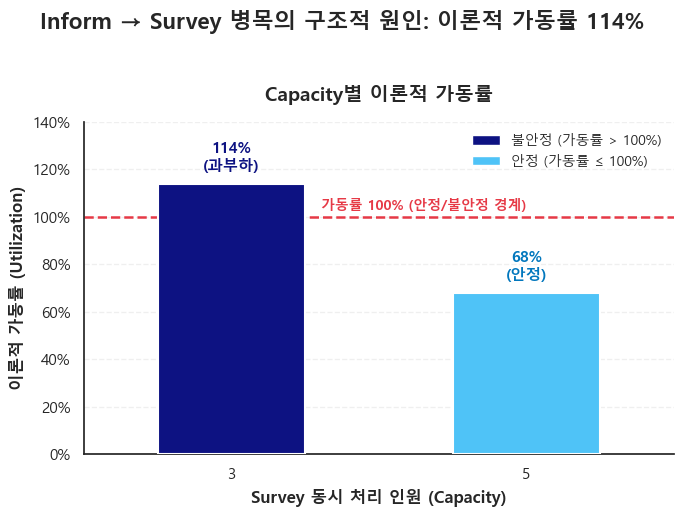

In [240]:
capacities = [3, 5]
utilizations = [1.14 , 0.68]
is_stable = [u <= 1.0 for u in utilizations]

# 파란색 계열 팔레트: 불안정(진한 남색/경고) vs 안정(하늘색 계열)
COLOR_UNSTABLE = "#0D1282"   # 과부하 구간 - 진한 남색
COLOR_STABLE = "#4FC3F7"     # 안정 구간 - 밝은 하늘색
COLOR_LINE = "#61677A"       # 기준선

bar_colors = [COLOR_UNSTABLE if not stable else COLOR_STABLE for stable in is_stable]

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5), facecolor="white")

# ------------------------------------------------------------
# 좌측: Capacity별 가동률
# ------------------------------------------------------------
x_pos = np.array([0, 0.6])

bar_width = 0.3

bars = ax1.bar(
    x_pos, # [str(c) for c in capacities],
    utilizations,
    color=bar_colors,
    width=bar_width,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# 100% 기준선
ax1.axhline(1.0, color="#E63946", linestyle="--", linewidth=1.8, zorder=2)
ax1.text(
    x_pos[1], 1.03,   # ← len(capacities)-0.5 대신 x_pos[1] 사용
    "가동률 100% (안정/불안정 경계)",
    color="#E63946", fontsize=10, fontweight="bold", ha="right"
)

# 막대 위 수치 라벨
for bar, util, stable in zip(bars, utilizations, is_stable):
    label = f"{util*100:.0f}%"
    status = "안정" if stable else "과부하"
    ax1.annotate(
        f"{label}\n({status})",
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color=COLOR_UNSTABLE if not stable else "#0277BD"
    )

ax1.set_xticks(x_pos)
ax1.set_xticklabels([str(c) for c in capacities])
ax1.set_xlim(
    x_pos[0] - bar_width,
    x_pos[-1] + bar_width
)
# ax1.set_xlim(-0.3, 0.9)

ax1.set_ylim(0, 1.4)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.set_xlabel("Survey 동시 처리 인원 (Capacity)", fontsize=12, fontweight="bold")
ax1.set_ylabel("이론적 가동률 (Utilization)", fontsize=12, fontweight="bold")
ax1.set_title("Capacity별 이론적 가동률", fontsize=14, fontweight="bold", pad=15)

ax1.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_UNSTABLE, label="불안정 (가동률 > 100%)"),
    Patch(facecolor=COLOR_STABLE, label="안정 (가동률 ≤ 100%)"),
]
ax1.legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=10)

fig.suptitle(
    "Inform → Survey 병목의 구조적 원인: 이론적 가동률 114%",
    fontsize=16, fontweight="bold", y=1.03
)

plt.tight_layout()
plt.savefig(
    "utilization_littles_law2",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [241]:
# SimPy Case Process
def repair_case(env, case, survey_resource, improvement_rate, priority_mode, is_vip_boost, results):
    """
    improvement_rate : 자동화로 인한 '실제 처리(service) 시간' 단축률 → survey_duration에 적용
    priority_mode     : "AS-IS" 또는 "PRIORITY" → 자원 배정 순서에만 영향, 큐 대기시간에서 발생
    """

    request_time = env.now
    
#    original_wait_hr = case["InformClientSurvey > Survey"] / 60   # 기존 이력상의 대기시간
    base_service_hr = case["survey_duration_hr"]                    # 기존 이력상의 실제 처리시간
    service_time_hr = base_service_hr * (1 - improvement_rate)      # 개선 적용된 처리시간 - survey_duration에 영향
    # priority = -case["priority_score"] if priority_mode == "PRIORITY" else 0

    if priority_mode == "PRIORITY":
        # 높은 priority_score가 먼저 처리되도록
        priority = -case["priority_score"]

        # 시나리오 B : VIP 최우선
        if (is_vip_boost and case["vip_segment"] == "VIP"):
            priority -= 1000

    else:
        # AS-IS: 선착순
        priority = 0
    
    with survey_resource.request(priority=priority) as request:
        yield request # 자원(survey_resource)을 기다림, capacity가 클수록 이 대기가 짧아짐
        actual_queue_wait_hr = env.now - request_time # Survey가 큐에 들어온 후 담당자 배정까지 기다린 시간
        yield env.timeout(service_time_hr) # 그 다음에 상담 진행
        
    simulated_lead_time = actual_queue_wait_hr + base_service_hr + case["post_survey_hr"]

    results.append({
        "caseID": case["caseID"],
        "lead_time_hr": simulated_lead_time,
        "queue_wait_hr": actual_queue_wait_hr,
        "service_time_hr": service_time_hr,
        "post_survey_hr" : case["post_survey_hr"],
        "repair_cost": case["repair_cost"],
        "priority_score": case["priority_score"],
        "vip_segment": case["vip_segment"],
    })

In [242]:
def case_generator(env, records, survey_resource, improvement_rate, priority_mode, is_vip_boost, results):

    records = sorted(records, key=lambda x: x["arrival_hr"])
    
    prev_time = 0.0
    for case in records:
        wait = max(0.0, case["arrival_hr"] - prev_time)
        yield env.timeout(wait)
        prev_time = case["arrival_hr"]
        env.process(repair_case(env, case, survey_resource, improvement_rate, priority_mode, is_vip_boost, results))


In [243]:
# 단일 시뮬레이션
def run_simulation(records, improvement_rate=0.0, priority_mode="AS-IS", capacity=3, is_vip_boost=False):
    results = []
    env = simpy.Environment()
    survey_resource = simpy.PriorityResource(env, capacity=capacity)
    env.process(case_generator(env, records, survey_resource, improvement_rate, priority_mode, is_vip_boost, results))
    env.run()
    return pd.DataFrame(results)

In [244]:
# KPI 계산
def calculate_metrics(result_df):
    return {
        "lead_time_hr": result_df["lead_time_hr"].mean(),
        "vip_lead_time_hr": result_df.loc[result_df["vip_segment"] == "VIP", "lead_time_hr"].mean(),
        "locked_capital_krw": (result_df["repair_cost"] * (result_df["lead_time_hr"] / 24)).sum(),
        "avg_queue_wait_hr": result_df["queue_wait_hr"].mean(),
        "max_queue_wait_hr": result_df["queue_wait_hr"].max(),   # 불안정 큐 특성상 최댓값도 같이 보는게 좋음
    }

In [245]:
as_is = run_simulation(base_records, improvement_rate=0.0, priority_mode="AS-IS", capacity=3)
cap5 = run_simulation(base_records, improvement_rate=0.0, priority_mode="AS-IS", capacity=5)

print(f"capacity=3, 평균 대기(Inform→Survey): {as_is['queue_wait_hr'].mean():.2f}h")
print(f"capacity=5, 평균 대기(Inform→Survey): {cap5['queue_wait_hr'].mean():.2f}h")

capacity=3, 평균 대기(Inform→Survey): 20.48h
capacity=5, 평균 대기(Inform→Survey): 0.10h


In [247]:
# 단일 실행(부트스트랩 없이)의 경우
as_is_single = run_simulation(base_records, priority_mode="AS-IS", capacity=3)

print("\n===== AS-IS 단일 실행 결과 (부트스트랩 전, 디버깅용) =====")
print(as_is_single[["queue_wait_hr", "service_time_hr", "post_survey_hr", "lead_time_hr"]].describe())
print(f"\n실측 원본 평균 리드타임: 105.87h")
print(f"시뮬레이션 평균 리드타임: {as_is_single['lead_time_hr'].mean():.2f}h")
print(f"시뮬레이션 평균 대기(queue_wait_hr): {as_is_single['queue_wait_hr'].mean():.2f}h")


===== AS-IS 단일 실행 결과 (부트스트랩 전, 디버깅용) =====
       queue_wait_hr  service_time_hr  post_survey_hr  lead_time_hr
count     927.000000       927.000000      927.000000    927.000000
mean       20.476969         0.675207       28.437379     49.589554
std        11.982517         0.205839       39.375782     42.870401
min         0.000000         0.250000        2.650000      5.383333
25%        10.591667         0.533333        8.900000     23.966667
50%        21.766667         0.683333       12.900000     38.250000
75%        30.416667         0.850000       26.058333     53.241667
max        40.816667         1.000000      262.616667    299.616667

실측 원본 평균 리드타임: 105.87h
시뮬레이션 평균 리드타임: 49.59h
시뮬레이션 평균 대기(queue_wait_hr): 20.48h


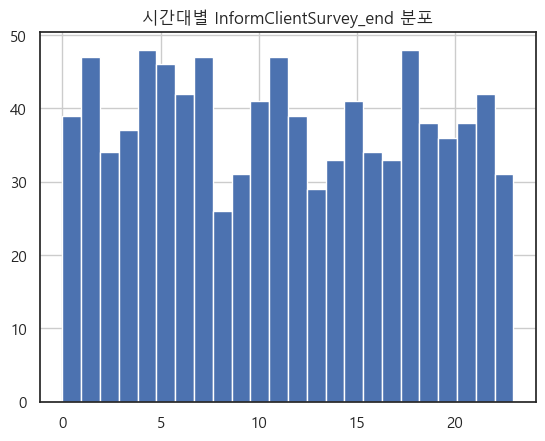

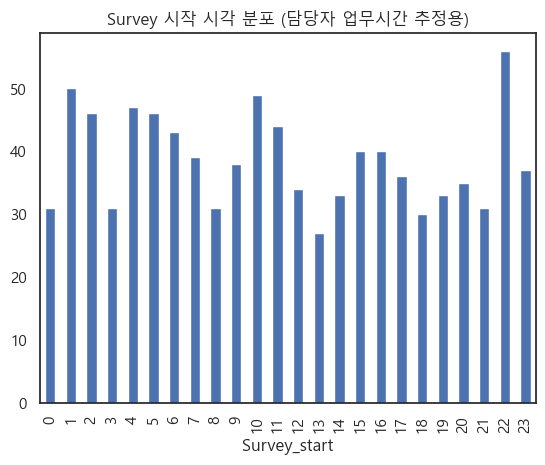

In [248]:
df["hour"] = df["InformClientSurvey_end"].dt.hour
df["weekday"] = df["InformClientSurvey_end"].dt.dayofweek  # 0=월요일

df["hour"].hist(bins=24)
plt.title("시간대별 InformClientSurvey_end 분포")
plt.show()

df.groupby(df["Survey_start"].dt.hour).size().plot(kind="bar")
plt.title("Survey 시작 시각 분포 (담당자 업무시간 추정용)")
plt.show()

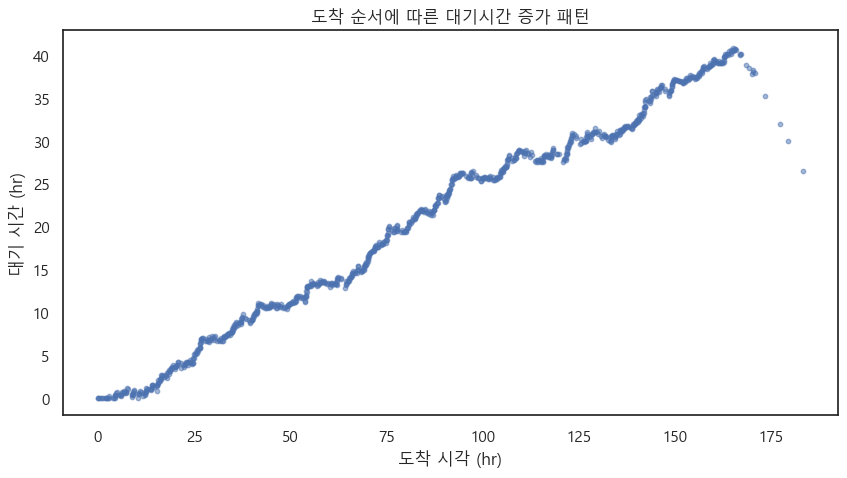

전반부(첫 50%) 평균 대기: 9.991828653707708
후반부(끝 50%) 평균 대기: 30.939511494252944


In [249]:
result = run_simulation(base_records, improvement_rate=0.0, priority_mode="AS-IS", capacity=3)

# arrival 순서와 queue_wait을 나란히 봐야 하므로 caseID로 arrival_hr 붙이기
result = result.merge(df_sorted[["caseID", "arrival_hr"]], on="caseID", how="left")
result = result.sort_values("arrival_hr")

plt.figure(figsize=(10,5))
plt.scatter(result["arrival_hr"], result["queue_wait_hr"], s=10, alpha=0.5)
plt.xlabel("도착 시각 (hr)")
plt.ylabel("대기 시간 (hr)")
plt.title("도착 순서에 따른 대기시간 증가 패턴")
plt.show()

print("전반부(첫 50%) 평균 대기:", result.iloc[:len(result)//2]["queue_wait_hr"].mean())
print("후반부(끝 50%) 평균 대기:", result.iloc[len(result)//2:]["queue_wait_hr"].mean())

#### ① 가동률과 누적 대기
- 관측 기간 동안 가동률이 1.14로 1을 초과하면서 대기시간이 지속적으로 누적되는 불안정 큐 형태가 관찰
- 다만 관측 기간이 짧아 후반부 케이스의 잔여 대기시간이 충분히 반영되지 않을 수 있어, 평균 대기시간만으로 실제 병목을 설명하기에는 한계가 있음.

→ 단순 Capacity 모델만으로 실제 대기 구조를 설명할 수 있는지 재검토

## 4-3. Simple Queue Model

In [252]:
# 개선안 1, 2 공통
# 도착 시각(arrival_hr)은 실측 스케줄로 고정하고,
# 각 도착 슬롯에 배정되는 케이스의 속성(비용/우선순위/처리시간)만 부트스트랩으로 리샘플링.
# → 실제 접수 패턴(몰리는 시점 등)은 유지하면서, 케이스 구성의 불확실성만 반영.
def run_scenario_monte_carlo(base_records, arrival_values, priority_mode, capacity,
                               improvement_rate=0.0, is_vip_boost=False, n_sim=100):    
    results = []
    for _ in range(n_sim):
        sampled_idx = np.random.randint(0, len(base_records), size=len(base_records))
        sample = [{**base_records[idx], "arrival_hr": arr} for idx, arr in zip(sampled_idx, arrival_values)]
        result = run_simulation(
            sample,
            improvement_rate=improvement_rate,
            priority_mode=priority_mode,
            capacity=capacity,
            is_vip_boost=is_vip_boost,
        )
        results.append(calculate_metrics(result))
    return pd.DataFrame(results).mean()

### Scenario A (AS-IS)

In [253]:
# 시나리오 A (as-is)

np.random.seed(42)

scenario_A = run_scenario_monte_carlo(base_records = base_records
                                      , arrival_values = arrival_values
                                      , priority_mode = "AS-IS"
                                      , capacity = 3
                                      , is_vip_boost = False
                                      , n_sim = 100
                                     )

print("===== 시나리오 A | As-is =====")
print(
    f"전체 Lead Time: "
    f"{scenario_A["lead_time_hr"]:.2f}h"
)

print(
    f"VIP Lead Time: "
    f"{scenario_A["vip_lead_time_hr"]:.2f}h"
)

print(
    f"Inform > Survey 대기: "
    f"{scenario_A["avg_queue_wait_hr"]:.2f}h"
)

print(
    f"동결 자본: "
    f"{scenario_A["locked_capital_krw"]:,.0f}원"
)

===== 시나리오 A | As-is =====
전체 Lead Time: 48.99h
VIP Lead Time: 54.26h
Inform > Survey 대기: 19.74h
동결 자본: 584,879,685원


### Scenario B - Priority

In [254]:
np.random.seed(42)

scenario_B = run_scenario_monte_carlo(base_records = base_records
                                      , arrival_values = arrival_values
                                      , priority_mode = "PRIORITY"
                                      , capacity = 3
                                      , is_vip_boost = True
                                      , n_sim = 100
                                     )

print("===== 시나리오 B | Priority + VIP =====")
print(
    f"전체 Lead Time: "
    f"{scenario_B["lead_time_hr"]:.2f}h"
)

print(
    f"VIP Lead Time: "
    f"{scenario_B["vip_lead_time_hr"]:.2f}h"
)

print(
    f"Inform > Survey 대기: "
    f"{scenario_B["avg_queue_wait_hr"]:.2f}h"
)

print(
    f"동결 자본: "
    f"{scenario_B["locked_capital_krw"]:,.0f}원"
)

===== 시나리오 B | Priority + VIP =====
전체 Lead Time: 49.03h
VIP Lead Time: 34.55h
Inform > Survey 대기: 19.78h
동결 자본: 462,837,574원


### Scenario C - Priority + Capacity 5

In [255]:
np.random.seed(42)

scenario_C = run_scenario_monte_carlo(base_records = base_records
                                      , arrival_values = arrival_values
                                      , priority_mode = "PRIORITY"
                                      , capacity = 5
                                      , is_vip_boost = False
                                      , n_sim = 100
                                     )

print("===== 시나리오 C | Priority + Capacity 5 =====")
print(
    f"전체 Lead Time: "
    f"{scenario_C["lead_time_hr"]:.2f}h"
)

print(
    f"VIP Lead Time: "
    f"{scenario_C["vip_lead_time_hr"]:.2f}h"
)

print(
    f"Inform > Survey 대기: "
    f"{scenario_C["avg_queue_wait_hr"]:.2f}h"
)

print(
    f"동결 자본: "
    f"{scenario_C["locked_capital_krw"]:,.0f}원"
)

===== 시나리오 C | Priority + Capacity 5 =====
전체 Lead Time: 29.37h
VIP Lead Time: 34.39h
Inform > Survey 대기: 0.12h
동결 자본: 362,580,675원


### Scenario D - Capacity 5

In [256]:
# Priority 없이 Capacity 3 → 5
# 대조군

np.random.seed(42)
scenario_D = run_scenario_monte_carlo(base_records = base_records
                                      , arrival_values = arrival_values
                                      , priority_mode = "AS-IS"
                                      , capacity = 5
                                      , is_vip_boost = False
                                      , n_sim = 100
                                     )

print("===== 시나리오 D | Capacity 5만 적용 =====")
print(
    f"전체 Lead Time: "
    f"{scenario_D["lead_time_hr"]:.2f}h"
)

print(
    f"VIP Lead Time: "
    f"{scenario_D["vip_lead_time_hr"]:.2f}h"
)

print(
    f"Inform > Survey 대기: "
    f"{scenario_D["avg_queue_wait_hr"]:.2f}h"
)

print(
    f"동결 자본: "
    f"{scenario_D["locked_capital_krw"]:,.0f}원"
)

===== 시나리오 D | Capacity 5만 적용 =====
전체 Lead Time: 29.37h
VIP Lead Time: 34.46h
Inform > Survey 대기: 0.12h
동결 자본: 362,973,450원


In [258]:
print(f"\n===== AS-IS(원래 배정) 대비 개선율 =====")
before_lead = scenario_A["lead_time_hr"].mean()
after_lead = scenario_C["lead_time_hr"].mean()
print(f"전체 리드타임: {before_lead:.2f}h → {after_lead:.2f}h (개선율 {(before_lead-after_lead)/before_lead*100:.1f}%)")


===== AS-IS(원래 배정) 대비 개선율 =====
전체 리드타임: 48.99h → 29.37h (개선율 40.1%)


## 4-4. 모델 검증
- 개선안 1·2 (A~D): 단일 survey_resource(capacity=N) 모델
              → improvement_rate, capacity, priority_mode가 핵심 변수

- 개선안 3 (E): 담당자별 개별 자원(agent_resources, 11명 각각 capacity=1) 모델
          → 배정 로직(누구에게 Survey를 배정하는지)이 핵심 변수
          → capacity, improvement_rate 개념 자체가 없음

    - Survey 만 보는게 아님
    - Immediate
    - intern
    를 같은 담당자 자원에서 경쟁하는 구조로 모델링함.

In [ ]:
# 담당자별 실제 처리 속도(survey_duration) 분포
agent_speed = (
    df.dropna(subset=["Survey_originator", "survey_duration_hr"])
    .groupby("Survey_originator")["survey_duration_hr"]
    .agg(["mean", "count"])
    .query("count >= 10")  # 표본이 너무 적은 담당자는 제외
    .sort_values("mean")
)
print(agent_speed)

overall_mean = df["survey_duration_hr"].mean()
top_quartile_mean = agent_speed["mean"].quantile(0.20)  # 가장 빠른 25%

reduction_pct = (overall_mean - top_quartile_mean) / overall_mean * 100
print(f"전체 평균 대비 상위 25% 담당자의 처리 속도 개선폭: {reduction_pct:.1f}%") # 28.7%

In [263]:
reliable_agents = agent_speed[agent_speed["count"] >= 50]  # 신뢰 가능한 표본 크기 기준
best_reliable = reliable_agents["mean"].min()
reduction_pct_v2 = (overall_mean - best_reliable) / overall_mean * 100

print(f"전체 평균 처리시간: {overall_mean:.3f}h")
print(f"표본 50건 이상 중 최속: {best_reliable:.3f}h")
print(f"표본 50건 이상 중 가장 빠른 담당자 기준 개선폭: {reduction_pct_v2:.1f}%")

전체 평균 처리시간: 0.675h
표본 50건 이상 중 최속: 0.601h
표본 50건 이상 중 가장 빠른 담당자 기준 개선폭: 11.0%


In [266]:
# 특정 시간대나 요일에 몰리나?
df["Survey_start_hour"] = df["Survey_start"].dt.hour # 시간
df["Survey_start_weekday"] = df["Survey_start"].dt.dayofweek  # 0=월요일

print(df["Survey_start_hour"].value_counts().sort_index())
print(df["Survey_start_weekday"].value_counts().sort_index())

# InformClientSurvey_end 이후 며칠 뒤에 Survey_start가 일어나는지 분포
gap_days = (df["Survey_start"] - df["InformClientSurvey_end"]).dt.total_seconds() / 3600 / 24
print(gap_days.describe())

Survey_start_hour
0     31
1     50
2     46
3     31
4     47
5     46
6     43
7     39
8     31
9     38
10    49
11    44
12    34
13    27
14    33
15    40
16    40
17    36
18    30
19    33
20    35
21    31
22    56
23    37
Name: count, dtype: int64
Survey_start_weekday
0    140
1    133
2    114
3    133
4    140
5    133
6    134
Name: count, dtype: int64
count    927.000000
mean       3.198340
std        3.267235
min        0.000000
25%        0.281250
50%        2.031944
75%        5.558333
max       13.652778
dtype: float64


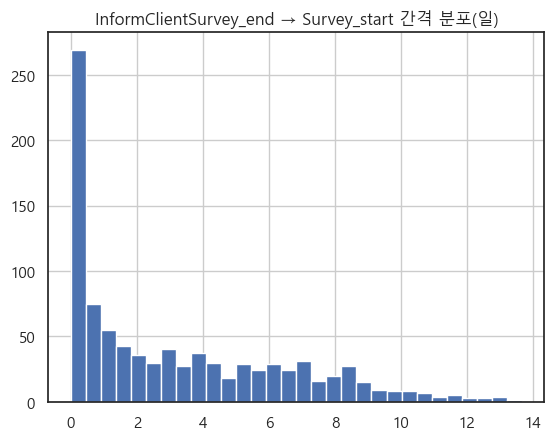

count    927.000000
mean       3.198340
std        3.267235
min        0.000000
25%        0.281250
50%        2.031944
75%        5.558333
max       13.652778
dtype: float64
          caseID       gap
caseID  1.000000  0.002798
gap     0.002798  1.000000


In [267]:
# gap_days 분포 모양 확인
gap_days.hist(bins=30)
plt.title("InformClientSurvey_end → Survey_start 간격 분포(일)")
plt.show()

print(gap_days.describe())

# caseID나 다른 변수와 상관관계가 있는지도 확인
print(df[["caseID"]].assign(gap=gap_days).corr())

#### ② 대기시간 분포
- InformClientSurvey → Survey 대기시간은 0~1.4일 구간에 약 43%가 집중되고, 이후 긴 꼬리를 보이는 분포
- 짧은 대기부터 최대 10~13일까지의 긴 대기가 함께 존재해, 단순히 Survey 처리시간이나 평균 Capacity만으로 설명하기 어려운 구조임

→ 실제 대기를 발생시키는 자원이 무엇인지 재검토

In [268]:
# 케이스 수(물량)와 평균 gap이 관련있는지 확인
case_count = df["Survey_originator"].value_counts()

gap_by_originator = df.groupby("Survey_originator").apply(
    lambda g: ((g["Survey_start"] - g["InformClientSurvey_end"]).dt.total_seconds()/3600/24).mean()
)

comparison = pd.DataFrame({"case_count": case_count, "avg_gap_days": gap_by_originator}).sort_values("avg_gap_days")
comparison

,case_count,avg_gap_days
Survey_originator,,
Ben,35,0.004147
Nick,33,0.006229
Eric,23,0.006703
Lex,27,0.007150
Anne,218,2.963338
Jacky,110,3.144722
Barbara,111,3.360191
John,101,3.830370
Edd,81,4.378352


#### ③ 담당자별 대기시간 편차
- 4명: 평균 대기 약 0.006일, 총 118건
- 7명: 평균 대기 약 3~4.6일, 총 809건

전체 케이스의 87%가 상대적으로 대기시간이 긴 7명에게 집중되어 있었으며, 담당자별 업무 배분이 균등하지 않은 구조

→ Capacity 자체보다 담당자별 배정 구조에 문제가 있을 가능성 확인

In [269]:
# 이 4명이 담당한 케이스의 특성이 나머지 7명과 다른지 확인
# 이 4명이 정말 "여유 인력"인지, 아니면 "다른 이유로 예외적인 소수"인지
low_wait_agents = ["Ben", "Nick", "Eric", "Lex"]
df["is_fast_agent"] = df["Survey_originator"].isin(low_wait_agents)

print(df.groupby("is_fast_agent")[["product_price", "priority_score"]].mean())
# 수리비는 평균 제품가가 약 약 239만원 vs 249만원라서 큰 차이가 있다고 보기는 어려움.

print(df.groupby("is_fast_agent")["product_category"].value_counts(normalize=True))

# 이 4명이 다른 담당자들과 근무 시간대가 다른지도 확인
print(df.groupby("is_fast_agent")["Survey_start"].apply(lambda x: x.dt.hour.mean()))

               product_price  priority_score
is_fast_agent                               
False           2.392360e+06        0.107441
True            2.491837e+06        0.123025
is_fast_agent  product_category
False          IT/소형가전             0.364648
               생활가전                0.317676
               대형가전                0.200247
               정밀/의료기기             0.117429
True           생활가전                0.322034
               IT/소형가전             0.313559
               대형가전                0.245763
               정밀/의료기기             0.118644
Name: proportion, dtype: float64
is_fast_agent
False    11.353523
True     10.483051
Name: Survey_start, dtype: float64


In [270]:
# 담당자 11명
SURVEY_AGENTS = ["Ben", "Nick", "Eric", "Lex", "Anne", "Jacky", "Barbara", "John", "Edd", "Cindy", "Paul"]

In [271]:
event_log_complete_only = event_log[event_log["eventtype"] == "complete"]

In [272]:
all_tasks_by_agent = (
    event_log_complete_only
    .groupby("originator")["taskID"]
    .value_counts()
    .unstack(fill_value=0)
)

all_tasks_by_agent["total_workload"] = (
    all_tasks_by_agent.sum(axis=1)
)

agent_workload = (
    all_tasks_by_agent
    .loc[
        SURVEY_AGENTS,
        ["Survey", "ImmediateRepair", "InternRepair", "total_workload"]
    ]
)

agent_workload.sort_values("total_workload")

taskID,Survey,ImmediateRepair,InternRepair,total_workload
originator,,,,
Eric,23,4,22,49
Nick,33,3,18,54
Lex,27,7,22,56
Ben,35,4,21,60
Edd,81,0,105,186
Cindy,94,0,100,194
Paul,94,0,100,194
John,101,0,97,198
Barbara,111,88,15,214


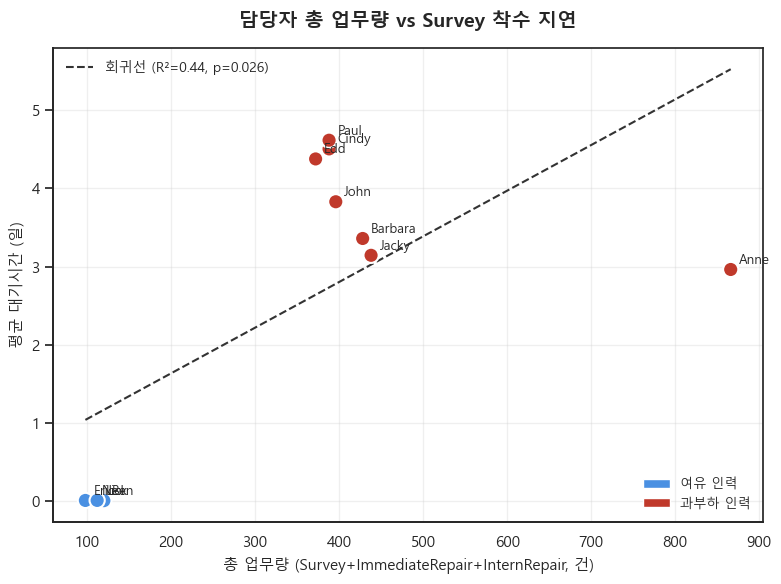

In [275]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

agents = ["Ben","Nick","Eric","Lex","Anne","Jacky","Barbara","John","Edd","Cindy","Paul"]
workload = [120, 108, 98, 112, 866, 438, 428, 396, 372, 388, 388]  # total_workload
gap_days = [0.004147, 0.006229, 0.006703, 0.007150, 2.963338, 3.144722, 3.360191, 3.830370, 4.378352, 4.506930, 4.617974]

slope, intercept, r_value, p_value, std_err = stats.linregress(workload, gap_days)

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

colors = ["#4A90E2"]*4 + ["#C0392B"]*7
ax.scatter(workload, gap_days, c=colors, s=120, zorder=3, edgecolor="white", linewidth=1.5)

for a, w, g in zip(agents, workload, gap_days):
    ax.annotate(a, (w, g), xytext=(6, 4), textcoords="offset points", fontsize=9.5)

x_line = np.linspace(min(workload), max(workload), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#333333", linestyle="--", linewidth=1.5, zorder=2,
        label=f"회귀선 (R²={r_value**2:.2f}, p={p_value:.3f})")

ax.set_title("담당자 총 업무량 vs Survey 착수 지연", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("총 업무량 (Survey+ImmediateRepair+InternRepair, 건)", fontsize=11)
ax.set_ylabel("평균 대기시간 (일)", fontsize=11)
ax.legend(loc="upper left", fontsize=10, frameon=False)
ax.grid(alpha=0.3, zorder=0)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

from matplotlib.patches import Patch
legend2 = [Patch(facecolor="#4A90E2", label="여유 인력"), Patch(facecolor="#C0392B", label="과부하 인력")]
ax2 = ax.twinx()
ax2.set_yticks([])
ax2.legend(handles=legend2, loc="lower right", fontsize=9.5, frameon=False)

plt.tight_layout()
plt.savefig("attempt3_scatter.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [277]:
# 한 담당자가 정말 "한 번에 한 케이스만" 처리하는지, 실측 데이터에서 겹치는 케이스가 있는지
# Anne이 담당한 케이스들의 Survey_start~Survey_end가 서로 겹치는지 확인
anne_cases = df[df["Survey_originator"] == "Anne"][["Survey_start", "Survey_end"]].sort_values("Survey_start")
print(anne_cases.head(20))

# 겹치는 케이스가 있는지 직접 확인
overlaps = 0
prev_end = None
for _, row in anne_cases.iterrows():
    if prev_end is not None and row["Survey_start"] < prev_end:
        overlaps += 1
    prev_end = row["Survey_end"]
print(f"\nAnne의 케이스 중 시간이 겹치는 건수: {overlaps} / {len(anne_cases)}")

           Survey_start          Survey_end
467 1970-01-01 10:18:00 1970-01-01 10:59:00
710 1970-01-01 11:17:00 1970-01-01 12:00:00
83  1970-01-01 13:39:00 1970-01-01 14:20:00
858 1970-01-01 14:12:00 1970-01-01 14:57:00
610 1970-01-01 16:32:00 1970-01-01 17:16:00
36  1970-01-01 16:45:00 1970-01-01 17:35:00
182 1970-01-01 19:35:00 1970-01-01 20:34:00
651 1970-01-01 21:16:00 1970-01-01 21:59:00
204 1970-01-01 22:22:00 1970-01-01 23:21:00
745 1970-01-01 23:59:00 1970-01-02 00:58:00
541 1970-01-02 01:33:00 1970-01-02 02:12:00
741 1970-01-02 04:00:00 1970-01-02 04:54:00
880 1970-01-02 05:22:00 1970-01-02 05:55:00
491 1970-01-02 06:42:00 1970-01-02 07:33:00
393 1970-01-02 07:55:00 1970-01-02 08:26:00
907 1970-01-02 09:21:00 1970-01-02 10:16:00
368 1970-01-02 10:26:00 1970-01-02 11:18:00
606 1970-01-02 13:06:00 1970-01-02 13:38:00
915 1970-01-02 15:26:00 1970-01-02 16:05:00
669 1970-01-02 16:28:00 1970-01-02 17:19:00

Anne의 케이스 중 시간이 겹치는 건수: 51 / 218


In [278]:
anne_hours = df[df["Survey_originator"]=="Anne"]["Survey_start"].dt.hour
print(anne_hours.value_counts().sort_index())

anne_days_active = df[df["Survey_originator"]=="Anne"]["Survey_start"].dt.date.nunique()
anne_total_cases = (df["Survey_originator"]=="Anne").sum()
print(f"\nAnne이 활동한 날짜 수: {anne_days_active}일")
print(f"Anne이 처리한 총 케이스: {anne_total_cases}건")
print(f"하루 평균 처리 건수: {anne_total_cases/anne_days_active:.1f}건")

Survey_start
0      6
1     11
2      9
3      7
4     11
5      8
6     10
7      9
8      6
9     11
10    14
11     4
12     8
13     8
14    10
15    11
16    10
17     9
18    10
19    12
20     5
21     8
22    13
23     8
Name: count, dtype: int64

Anne이 활동한 날짜 수: 14일
Anne이 처리한 총 케이스: 218건
하루 평균 처리 건수: 15.6건


In [279]:
# ============================================================
# ImmediateRepair
# ============================================================

immediate_repair_df = event_log[event_log["taskID"] == "ImmediateRepair"].copy()
immediate_repair_df = immediate_repair_df.sort_values(["caseID", "originator", "timestamp"])
immediate_repair_df["seq"] = immediate_repair_df.groupby(["caseID", "originator", "eventtype"]).cumcount()

imm_start = immediate_repair_df[immediate_repair_df["eventtype"] == "start"][
    ["caseID", "originator", "seq", "timestamp"]
].rename(columns={"timestamp": "start"})

imm_complete = immediate_repair_df[immediate_repair_df["eventtype"] == "complete"][
    ["caseID", "originator", "seq", "timestamp"]
].rename(columns={"timestamp": "complete"})

immediate_merged = imm_start.merge(imm_complete, on=["caseID", "originator", "seq"])

immediate_merged["duration_hr"] = (immediate_merged["complete"] - immediate_merged["start"]).dt.total_seconds() / 3600
immediate_merged["arrival_hr"] = (
    immediate_merged["start"] - df_sorted["InformClientSurvey_end"].min()
).dt.total_seconds() / 3600

immediate_merged = immediate_merged[immediate_merged["originator"].isin(SURVEY_AGENTS)]
immediate_merged = immediate_merged[immediate_merged["duration_hr"] >= 0]  # 방어적 필터

print(f"ImmediateRepair 건수(11명 대상): {len(immediate_merged)}")
print(immediate_merged[["originator", "duration_hr", "arrival_hr"]].describe())

ImmediateRepair 건수(11명 대상): 383
       duration_hr  arrival_hr
count   383.000000  383.000000
mean      1.945431  152.824151
std       0.270783   90.966106
min       0.700000    0.916667
25%       1.800000   72.700000
50%       2.000000  148.550000
75%       2.200000  229.616667
max       2.200000  315.650000


In [280]:
# ImmediateRepair가 한 케이스에서 몇 번씩 나오는지 확인
immediate_counts = immediate_repair_df[immediate_repair_df["eventtype"]=="start"].groupby("caseID").size()
print(immediate_counts.value_counts())  # 대부분 1이어야 정상, 2 이상이 많으면 재수리 패턴 존재

1    383
Name: count, dtype: int64


In [281]:
# ============================================================
# InternRepair
# ============================================================

intern_repair_df = event_log[event_log["taskID"] == "InternRepair"].copy()
intern_repair_df = intern_repair_df.sort_values(["caseID", "originator", "timestamp"])
intern_repair_df["seq"] = intern_repair_df.groupby(["caseID", "originator", "eventtype"]).cumcount()

intern_start = intern_repair_df[intern_repair_df["eventtype"] == "start"][
    ["caseID", "originator", "seq", "timestamp"]
].rename(columns={"timestamp": "start"})

intern_complete = intern_repair_df[intern_repair_df["eventtype"] == "complete"][
    ["caseID", "originator", "seq", "timestamp"]
].rename(columns={"timestamp": "complete"})

intern_merged = intern_start.merge(intern_complete, on=["caseID", "originator", "seq"])

intern_merged["duration_hr"] = (intern_merged["complete"] - intern_merged["start"]).dt.total_seconds() / 3600
intern_merged["arrival_hr"] = (
    intern_merged["start"] - df_sorted["InformClientSurvey_end"].min()
).dt.total_seconds() / 3600

intern_merged = intern_merged[intern_merged["originator"].isin(SURVEY_AGENTS)]
intern_merged = intern_merged[intern_merged["duration_hr"] >= 0]  # 방어적 필터

print(f"InternRepair 건수(11명 대상): {len(intern_merged)}")
print(intern_merged[["originator", "duration_hr", "arrival_hr"]].describe())

InternRepair 건수(11명 대상): 547
       duration_hr  arrival_hr
count   547.000000  547.000000
mean      3.737355  202.461182
std       0.622512  129.816284
min       1.800000    0.700000
25%       3.600000   91.250000
50%       3.666667  180.366667
75%       4.033333  312.975000
max       4.800000  448.533333


In [282]:
intern_counts = intern_repair_df[intern_repair_df["eventtype"]=="start"].groupby("caseID").size()
print(intern_counts.value_counts())  # 대부분 1이어야 정상, 2 이상이 많으면 재수리 패턴 존재

1    470
2     37
3      1
Name: count, dtype: int64


In [283]:
# 세 업무를 하나의 담당자 자원으로 통합
# ============================================================
# Survey
# ============================================================

survey_events = df_sorted[df_sorted["Survey_originator"].isin(SURVEY_AGENTS)][
    ["caseID", "Survey_originator", "arrival_hr", "survey_duration_hr", "post_survey_hr",
     "repair_cost", "priority_score", "vip_segment"]
    ].rename(columns = {"Survey_originator": "originator", "survey_duration_hr": "duration_hr"})
survey_events["task_type"] = "Survey"


# ============================================================
# ImmediateRepair
# ============================================================

immediate_events = immediate_merged[["caseID", "originator", "arrival_hr", "duration_hr"]].copy()
immediate_events["task_type"] = "ImmediateRepair"
immediate_events["post_survey_hr"] = 0
immediate_events["repair_cost"] = 0
immediate_events["priority_score"] = -1  # Survey 결과 집계에서 제외하되, 자원은 점유
immediate_events["vip_segment"] = "N/A"


# ============================================================
# InternRepair
# ============================================================

intern_events = intern_merged[["caseID", "originator", "arrival_hr", "duration_hr"]].copy()
intern_events["task_type"] = "InternRepair"
intern_events["post_survey_hr"] = 0
intern_events["repair_cost"] = 0
intern_events["priority_score"] = -1     # Survey 결과 집계 대상 아님 (자원만 점유)
intern_events["vip_segment"] = "N/A"


# ============================================================
# 통합 이벤트
# ============================================================

all_events = pd.concat(
    [survey_events, immediate_events, intern_events],
    ignore_index=True
).sort_values("arrival_hr").reset_index(drop=True)

print("===== 통합 이벤트 =====")
print(f"Survey          : {len(survey_events)}")
print(f"ImmediateRepair : {len(immediate_events)}")
print(f"InternRepair    : {len(intern_events)}")
print(f"Total           : {len(all_events)}")

===== 통합 이벤트 =====
Survey          : 927
ImmediateRepair : 383
InternRepair    : 547
Total           : 1857


In [284]:
# 담당자별로 세부 breakdown (Survey/Immediate/Intern 각각 몇 건, 몇 시간씩인지)
for agent in ["Anne", "Jacky", "Barbara"]:
    print(f"\n===== {agent} =====")
    print(f"Survey: {len(survey_events[survey_events['originator']==agent])}건, "
          f"평균 {survey_events[survey_events['originator']==agent]['duration_hr'].mean():.2f}h")
    print(f"ImmediateRepair: {len(immediate_events[immediate_events['originator']==agent])}건, "
          f"평균 {immediate_events[immediate_events['originator']==agent]['duration_hr'].mean():.2f}h")
    print(f"InternRepair: {len(intern_events[intern_events['originator']==agent])}건, "
          f"평균 {intern_events[intern_events['originator']==agent]['duration_hr'].mean():.2f}h")


===== Anne =====
Survey: 218건, 평균 0.75h
ImmediateRepair: 185건, 평균 1.99h
InternRepair: 30건, 평균 3.31h

===== Jacky =====
Survey: 110건, 평균 0.76h
ImmediateRepair: 92건, 평균 2.01h
InternRepair: 17건, 평균 2.85h

===== Barbara =====
Survey: 111건, 평균 0.78h
ImmediateRepair: 88건, 평균 1.98h
InternRepair: 15건, 평균 3.64h


In [285]:
# John/Edd/Cindy/Paul의 InternRepair 시간이 정말 짧게 잡혔는지 확인
for agent in ["John", "Edd", "Cindy", "Paul"]:
    durations = intern_events[intern_events["originator"] == agent]["duration_hr"]
    print(f"{agent}: InternRepair {len(durations)}건, 평균 {durations.mean():.2f}h, 최대 {durations.max():.2f}h, 표준편차 {durations.std():.2f}")

# 혹시 이 InternRepair 안에도 극단적으로 긴 케이스(며칠짜리)가 섞여있는지
print("\nJohn의 InternRepair 상위 10개(가장 긴 것):")
print(intern_events[intern_events["originator"]=="John"].sort_values("duration_hr", ascending=False).head(10))

John: InternRepair 97건, 평균 3.98h, 최대 4.40h, 표준편차 0.34
Edd: InternRepair 105건, 평균 3.83h, 최대 4.40h, 표준편차 0.34
Cindy: InternRepair 100건, 평균 3.89h, 최대 4.40h, 표준편차 0.35
Paul: InternRepair 100건, 평균 3.90h, 최대 4.40h, 표준편차 0.37

John의 InternRepair 상위 10개(가장 긴 것):
     caseID originator  arrival_hr  duration_hr     task_type  post_survey_hr  \
365     703       John   81.800000          4.4  InternRepair               0   
486     910       John  425.200000          4.4  InternRepair               0   
377     722       John  166.183333          4.4  InternRepair               0   
137     269       John  351.316667          4.4  InternRepair               0   
153     306       John  204.983333          4.4  InternRepair               0   
169     328       John  102.116667          4.4  InternRepair               0   
177     343       John   68.850000          4.4  InternRepair               0   
185     355       John   48.716667          4.4  InternRepair               0   
210     400     

## 4-5. Integrated Resource Model

In [286]:
def process_event(env, event, agent_resources, results):
    request_time = env.now
    resource = agent_resources[event["originator"]]

    with resource.request() as request:
        yield request
        actual_start = env.now
        wait_hr = actual_start - request_time
        yield env.timeout(event["duration_hr"])

    # Survey만 KPI 기록
    if event["task_type"] == "Survey":
        lead_time_hr = (wait_hr + event["duration_hr"] + event["post_survey_hr"])

        results.append({
            "caseID": event["caseID"],
            "originator": event["originator"],
            "queue_wait_hr": wait_hr,
            "lead_time_hr": lead_time_hr,
            "repair_cost": event["repair_cost"],
            "priority_score": event["priority_score"],
            "vip_segment": event["vip_segment"]
        })
    # ImmediateRepair는 결과 집계 대상이 아니라, 자원을 점유해 Survey를 지연시키는 역할만 함


def event_generator(env, events, agent_resources, results):
    
    for _, event in events.sort_values("arrival_hr").iterrows():

        # 현재 시각보다 이벤트 도착시각이 미래면 이동
        if env.now < event["arrival_hr"]:
            yield env.timeout(event["arrival_hr"] - env.now)

        # 이벤트를 해당 담당자에게 투입
        env.process(process_event(env, event, agent_resources, results))


def run_integrated_simulation(events, agents):

    env = simpy.Environment()
    agent_resources = {agent: simpy.Resource(env, capacity=1) for agent in agents}

    results = []

    env.process(event_generator(env, events, agent_resources, results))
    env.run()

    return pd.DataFrame(results)

### AS-IS (통합모델)

In [287]:
as_is_integrated = run_integrated_simulation(
    all_events,
    SURVEY_AGENTS
)

print("===== AS-IS 통합 Resource 모델 =====")

print(
    f"Inform → Survey 평균 대기: "
    f"{as_is_integrated['queue_wait_hr'].mean():.2f}h"
)

print(
    f"평균 Survey 처리시간: "
    f"{survey_events['duration_hr'].mean():.2f}h"
)

print(
    f"평균 Lead Time: "
    f"{as_is_integrated['lead_time_hr'].mean():.2f}h"
)

print("\n[실측 기준]")
print("Inform → Survey: 76.76h")
print("Overall Lead Time: 105.87h")

===== AS-IS 통합 Resource 모델 =====
Inform → Survey 평균 대기: 41.52h
평균 Survey 처리시간: 0.68h
평균 Lead Time: 70.63h

[실측 기준]
Inform → Survey: 76.76h
Overall Lead Time: 105.87h


In [288]:
# ============================================================
# AS-IS 기준값 저장
# ============================================================

as_is_wait = as_is_integrated["queue_wait_hr"].mean()
as_is_lead = as_is_integrated["lead_time_hr"].mean()

print("===== AS-IS 기준값 =====")
print(f"Inform → Survey 대기: {as_is_wait:.2f}h")
print(f"평균 Lead Time:       {as_is_lead:.2f}h")

===== AS-IS 기준값 =====
Inform → Survey 대기: 41.52h
평균 Lead Time:       70.63h


### 겸직 업무량 재배분 분석

In [273]:
# 총 업무량과 Survey 착수 지연의 관계
summary_E = pd.DataFrame({
    "survey_count" : agent_workload.loc[SURVEY_AGENTS, "Survey"]
    , "total_workload" : agent_workload.loc[SURVEY_AGENTS, "total_workload"]
    , "avg_gap_days" : gap_by_originator.reindex(SURVEY_AGENTS) # survey - inform client survey
}).dropna()

slope, intercept, r_value, p_value, std_err = (
    stats.linregress(summary_E["total_workload"], summary_E["avg_gap_days"])
)

print(f"상관계수 r = {r_value:.3f}")
print(f"R² = {r_value**2:.3f}")
print(f"p-value = {p_value:.4f}")
print(f"회귀식: "
f"gap = {slope:.5f} × workload "
f"+ {intercept:.3f}")

상관계수 r = 0.663
R² = 0.440
p-value = 0.0261
회귀식: gap = 0.01169 × workload + 0.465


#### ④ 겸직 업무량 분석
- 담당자별 업무 구성을 비교한 결과, Survey 외에 ImmediateRepair와 InternRepair을 함께 수행하는 담당자에게 업무가 집중
- 특히 Anne은 Survey 218건과 ImmediateRepair 185건을 담당한 반면, 일부 담당자는 ImmediateRepair를 거의 수행하지 않음.
- 업무량이 많은 담당자의 Survey 배정을 줄이고 상대적으로 업무량이 적은 담당자에게 재배정하는 방식으로 시뮬레이션한 결과, 전체 대기시간이 감소하는 방향을 확인

- 총 업무량과 Survey 대기시간 간에는 양의 상관관계
(r = 0.66, R² = 0.44, p = 0.026)

→ Survey 대기시간 차이가 단순한 담당자별 배정량뿐 아니라, **겸직 업무로 인한 총 업무량 차이**와 관련되어 있을 가능성을 확인

In [274]:
# ============================================================
# 3. 재배정 후 예상 gap
# 업무량을 균등하게 재배분한다는 가정만 놓고 보면 대기시간이 얼마나 개선될 것으로 예상되는가?
# ============================================================
# Survey 재배분 비율 계산
# 업무량이 적은 담당자에게 Survey를 더 많이 배분
total_survey_cases = summary_E["survey_count"].sum()

# 업무량이 적을수록 더 많은 Survey를 받도록, min-max 정규화 후 역수 가중치
workload_norm = (summary_E["total_workload"] 
                 - summary_E["total_workload"].min()
                ) / \
                (summary_E["total_workload"].max() 
                 - summary_E["total_workload"].min()
                )

inverse_weight = 1 - workload_norm + 0.1  # 0이 되지 않도록 바닥값, 업무량이 적은 담당자에게 Survey Case를 더 배분

rebalanced_share = inverse_weight / inverse_weight.sum()

summary_E["rebalanced_survey_count"] = (rebalanced_share * total_survey_cases).round()

summary_E["rebalanced_workload"] = (
    summary_E["total_workload"] - summary_E["survey_count"] + summary_E["rebalanced_survey_count"]
)
summary_E["predicted_gap_after"] = (slope * summary_E["rebalanced_workload"] + intercept).clip(lower=0)

print("\n===== 재배정 후 예상 평균 대기(gap) =====")
print(summary_E[["avg_gap_days", "predicted_gap_after"]].sort_values("avg_gap_days"))

before = (summary_E["avg_gap_days"] * summary_E["survey_count"]).sum() / summary_E["survey_count"].sum()
after = (summary_E["predicted_gap_after"] * summary_E["rebalanced_survey_count"]).sum() / summary_E["rebalanced_survey_count"].sum()
print(f"\n전체 가중평균 대기시간: {before:.2f}일 → {after:.2f}일 (개선율 {(before-after)/before*100:.1f}%)")


===== 재배정 후 예상 평균 대기(gap) =====
         avg_gap_days  predicted_gap_after
Ben          0.004147             2.101865
Nick         0.006229             2.066797
Eric         0.006703             2.148624
Lex          0.007150             2.160313
Anne         2.963338             3.107167
Jacky        3.144722             2.557758
Barbara      3.360191             2.511000
John         3.830370             2.487621
Edd          4.378352             2.616206
Cindy        4.506930             2.534379
Paul         4.617974             2.534379

전체 가중평균 대기시간: 3.20일 → 2.34일 (개선율 27.0%)


#### ⑤ 회귀 기반 재배정 검증
- 담당자의 총 업무량이 증가할수록 Survey 착수가 지연되는 경향이 있음
- 다만 담당자 11명을 대상으로 한 회귀분석과 근사 시뮬레이션이므로, 도출된 개선율을 실제 운영의 확정적인 예측값으로 해석하지 않고 **업무 재배분의 개선 가능성을 확인하는 참고 결과**로 활용

In [289]:
# ============================================================
# 업무량 기반 Survey 재배분
# ============================================================

# 1. 담당자별 총 업무량(Survey 제외한 나머지, 즉 "고정 부담") 계산
fixed_workload = (
    all_tasks_by_agent.loc[SURVEY_AGENTS, "ImmediateRepair"]
    +
    all_tasks_by_agent.loc[SURVEY_AGENTS, "InternRepair"]
)

print("===== 담당자별 고정 업무량 =====")
print(fixed_workload.sort_values())


# ------------------------------------------------------------
# 고정 업무량이 적을수록 Survey를 더 많이 배분
# ------------------------------------------------------------

workload_norm = (fixed_workload - fixed_workload.min()) / (fixed_workload.max() - fixed_workload.min())
inverse_weight = 1 - workload_norm + 0.1  # 0이 되지 않도록 바닥값
rebalanced_share = inverse_weight / inverse_weight.sum()


# ------------------------------------------------------------
# 정확히 927건 배분
# Largest Remainder 방식
# ------------------------------------------------------------

total_survey = len(survey_events)

raw_counts = (rebalanced_share * total_survey)

target_survey_count = np.floor(raw_counts).astype(int)

remaining = (total_survey - target_survey_count.sum())

remainders = (raw_counts - target_survey_count).sort_values(ascending=False)

for agent in remainders.index[:remaining]:
    target_survey_count.loc[agent] += 1


print("\n===== Scenario E 목표 Survey 배분 =====")

allocation_check = pd.DataFrame({
    "fixed_workload": fixed_workload,
    "weight": inverse_weight,
    "share": rebalanced_share,
    "target_survey_count": target_survey_count
}).sort_values("fixed_workload")

print(
    f"\n총 Survey: "
    f"{target_survey_count.sum()}건"
)

===== 담당자별 고정 업무량 =====
originator
Nick        21
Ben         25
Eric        26
Lex         29
John        97
Cindy      100
Paul       100
Barbara    103
Edd        105
Jacky      109
Anne       215
dtype: int64

===== Scenario E 목표 Survey 배분 =====

총 Survey: 927건


In [290]:
allocation_check

,fixed_workload,weight,share,target_survey_count
originator,,,,
Nick,21,1.100000,0.129459,120
Ben,25,1.079381,0.127032,118
Eric,26,1.074227,0.126426,117
Lex,29,1.058763,0.124606,115
John,97,0.708247,0.083354,77
Cindy,100,0.692784,0.081534,76
Paul,100,0.692784,0.081534,76
Barbara,103,0.677320,0.079714,74
Edd,105,0.667010,0.078500,73


In [291]:
# ============================================================
# 실제 Survey Case의 담당자만 재배정
# ============================================================

# 3. 실제 survey_events의 originator를 재배정 (caseID는 그대로, 담당자만 교체)
# 각 담당자의 목표 건수만큼, 원래 순서(arrival_hr 순)를 유지하며 라운드로빈 배정
survey_events_E = survey_events.copy().sort_values("arrival_hr").reset_index(drop=True)


# 담당자별 목표 건수를 순서대로 생성
agent_pool = []

for agent in SURVEY_AGENTS:
    agent_pool.extend([agent] * int(target_survey_count.loc[agent]))

# 재현 가능한 순서 섞기
rng = np.random.default_rng(42)
rng.shuffle(agent_pool) # 순서 섞어서 특정 시간대에 몰리지 않
survey_events_E["originator"] = agent_pool


print("\n===== Scenario E 실제 배정 결과 =====")
print(
    survey_events_E["originator"]
    .value_counts()
    .reindex(SURVEY_AGENTS)
) # 시나리오 E에서 각 담당자에게 배분되는 Survey 건수


===== Scenario E 실제 배정 결과 =====
originator
Ben        118
Nick       120
Eric       117
Lex        115
Anne        11
Jacky       70
Barbara     74
John        77
Edd         73
Cindy       76
Paul        76
Name: count, dtype: int64


### Scenario E

In [292]:
# 시나리오 E 대기시간 실행
# 4. ImmediateRepair, InternRepair는 원래 담당자 그대로 유지 (재배정 대상 아님)
all_events_E = pd.concat(
    [survey_events_E, immediate_events, intern_events],
    ignore_index=True
).sort_values("arrival_hr").reset_index(drop=True)


# 5. 재배정 시나리오 실행
scenario_E_result = run_integrated_simulation(all_events_E, SURVEY_AGENTS)

print(f"\n===== Scenario E (업무 재배분) =====")

print(
    f"Inform → Survey 평균 대기: "
    f"{scenario_E_result['queue_wait_hr'].mean():.2f}h"
)

print(
    f"평균 Lead Time: "
    f"{scenario_E_result['lead_time_hr'].mean():.2f}h"
)

print(
    f"VIP 평균 Lead Time: "
    f"{scenario_E_result.loc[
        scenario_E_result["vip_segment"] == "VIP",
        "lead_time_hr"
    ].mean():.2f}h"
)
#capital_E = (scenario_E_result["repair_cost"] * (scenario_E_result["lead_time_hr"]/24)).sum()
#print(f"동결 자본: {capital_E:,.0f}원")


===== Scenario E (업무 재배분) =====
Inform → Survey 평균 대기: 8.10h
평균 Lead Time: 37.22h
VIP 평균 Lead Time: 43.00h


In [293]:
scenario_E_wait = scenario_E_result["queue_wait_hr"].mean()
scenario_E_lead = scenario_E_result["lead_time_hr"].mean()

print("===== Scenario E 기준값 =====")
print(f"Inform → Survey 대기: {as_is_wait:.2f}h")
print(f"평균 Lead Time:       {as_is_lead:.2f}h")

===== Scenario E 기준값 =====
Inform → Survey 대기: 41.52h
평균 Lead Time:       70.63h


In [294]:
wait_reduction = ((as_is_wait - scenario_E_wait) / as_is_wait * 100)
lead_reduction = ((as_is_lead - scenario_E_lead) / as_is_lead * 100)

print("===== 개선 효과 =====")
print(f"Inform → Survey 대기 감소율: {wait_reduction:.1f}%")
print(f"평균 Lead Time 감소율:       {lead_reduction:.1f}%")

===== 개선 효과 =====
Inform → Survey 대기 감소율: 80.5%
평균 Lead Time 감소율:       47.3%


In [296]:
# 담당자별 결과 확인
scenario_E_agent = (
    scenario_E_result[
        ["caseID", "originator", "queue_wait_hr", "lead_time_hr"]
    ]
    .groupby("originator")
    .agg(
        survey_count=("caseID", "count"),
        avg_wait_hr=("queue_wait_hr", "mean"),
        avg_lead_time_hr=("lead_time_hr", "mean")
    )
    .reindex(SURVEY_AGENTS)
)

scenario_E_agent["avg_wait_days"] = (scenario_E_agent["avg_wait_hr"] / 24)

scenario_E_agent["avg_lead_time_days"] = (scenario_E_agent["avg_lead_time_hr"] / 24)

scenario_E_agent.sort_values(by = "survey_count")

,survey_count,avg_wait_hr,avg_lead_time_hr,avg_wait_days,avg_lead_time_days
originator,,,,,
Anne,11,39.596970,63.237879,1.649874,2.634912
Jacky,70,4.122143,35.043571,0.171756,1.460149
Edd,73,18.351826,46.294292,0.764659,1.928929
Barbara,74,4.397973,42.305180,0.183249,1.762716
Cindy,76,16.178947,46.528070,0.674123,1.938670
Paul,76,13.474561,37.441447,0.561440,1.560060
John,77,13.592208,36.133333,0.566342,1.505556
Lex,115,5.444638,29.524058,0.226860,1.230169
Eric,117,4.582621,35.233191,0.190943,1.468050


In [295]:
# ============================================================
# AS-IS vs Scenario E 전체 성과 비교
# ============================================================

comparison = pd.DataFrame({
    "AS_IS": [
        as_is_integrated["queue_wait_hr"].mean(),
        as_is_integrated["lead_time_hr"].mean()
    ],
    "Scenario_E": [
        scenario_E_result["queue_wait_hr"].mean(),
        scenario_E_result["lead_time_hr"].mean()
    ]
}, index=[
    "Inform → Survey 대기시간(h)",
    "평균 Lead Time(h)"
])

comparison["개선율(%)"] = (
    (comparison["AS_IS"] - comparison["Scenario_E"])
    / comparison["AS_IS"]
    * 100
)

comparison.round(2)

,AS_IS,Scenario_E,개선율(%)
Inform → Survey 대기시간(h),41.52,8.10,80.48
평균 Lead Time(h),70.63,37.22,47.31


47.3%면 개선안2(시나리오D 개선율 - 40.1%)보다도 나은 수치고, 심지어 인력 증원 없이 배정만 바꿔서 얻은 효과.

In [297]:
# ============================================================
# 담당자별 Survey 대기시간 비교
# ============================================================

as_is_agent = (
    as_is_integrated
    .groupby("originator")
    .agg(
        survey_count=("caseID", "count"),
        avg_wait_hr=("queue_wait_hr", "mean"),
        avg_lead_time_hr=("lead_time_hr", "mean")
    )
)

scenario_E_agent = (
    scenario_E_result
    .groupby("originator")
    .agg(
        survey_count=("caseID", "count"),
        avg_wait_hr=("queue_wait_hr", "mean"),
        avg_lead_time_hr=("lead_time_hr", "mean")
    )
)

agent_comparison = pd.DataFrame(index=SURVEY_AGENTS)

agent_comparison["AS_IS_Survey"] = (
    as_is_agent["survey_count"]
)

agent_comparison["Scenario_E_Survey"] = (
    scenario_E_agent["survey_count"]
)

agent_comparison["AS_IS_Wait_h"] = (
    as_is_agent["avg_wait_hr"]
)

agent_comparison["Scenario_E_Wait_h"] = (
    scenario_E_agent["avg_wait_hr"]
)

agent_comparison["Wait_개선율_%"] = (
    (
        agent_comparison["AS_IS_Wait_h"]
        - agent_comparison["Scenario_E_Wait_h"]
    )
    / agent_comparison["AS_IS_Wait_h"]
    * 100
)

agent_comparison.sort_values(by = "Scenario_E_Survey").round(2)

,AS_IS_Survey,Scenario_E_Survey,AS_IS_Wait_h,Scenario_E_Wait_h,Wait_개선율_%
Anne,218,11,124.91,39.60,68.30
Jacky,110,70,20.31,4.12,79.71
Edd,81,73,16.18,18.35,-13.39
Barbara,111,74,21.23,4.40,79.28
Cindy,94,76,19.12,16.18,15.36
Paul,94,76,18.96,13.47,28.93
John,101,77,17.46,13.59,22.17
Lex,27,115,0.13,5.44,-3946.02
Eric,23,117,0.13,4.58,-3513.72
Ben,35,118,0.05,2.99,-5706.97


In [298]:
# ============================================================
# 담당자별 업무량 / Survey 배분 변화
# ============================================================

agent_allocation = pd.DataFrame(index=SURVEY_AGENTS)

agent_allocation["Repair_Workload"] = (fixed_workload)

agent_allocation["AS_IS_Survey"] = (as_is_agent["survey_count"])

agent_allocation["Scenario_E_Survey"] = (scenario_E_agent["survey_count"])

agent_allocation["Survey_변화"] = ( agent_allocation["Scenario_E_Survey"] - agent_allocation["AS_IS_Survey"])

agent_allocation = (agent_allocation.sort_values("Repair_Workload"))

agent_allocation.sort_values(by = "Scenario_E_Survey").round(2)

,Repair_Workload,AS_IS_Survey,Scenario_E_Survey,Survey_변화
Anne,215,218,11,-207
Jacky,109,110,70,-40
Edd,105,81,73,-8
Barbara,103,111,74,-37
Cindy,100,94,76,-18
Paul,100,94,76,-18
John,97,101,77,-24
Lex,29,27,115,88
Eric,26,23,117,94
Ben,25,35,118,83


In [299]:
corr = (agent_allocation[["Repair_Workload", "Scenario_E_Survey"]]
    .corr()
    .iloc[0, 1]
)

print(
    f"\nRepair 업무량 ↔ Scenario E Survey 배분 "
    f"상관계수: {corr:.3f}"
) # 음수가 나와야 함 -> (설계한 repair 업무량 증가 -> Survey 배분 감소 방향과 일치)


Repair 업무량 ↔ Scenario E Survey 배분 상관계수: -1.000


In [301]:
# ============================================================
# VIP Lead Time 비교
# ============================================================

def get_vip_lead_time(result_df):
    
    vip = result_df[result_df["vip_segment"] == "VIP"]
    
    return {"count": len(vip),"avg_lead_time_hr": vip["lead_time_hr"].mean()}


vip_as_is = get_vip_lead_time(as_is_integrated)

vip_scenario_E = get_vip_lead_time(scenario_E_result)

vip_comparison = pd.DataFrame({
    "AS_IS": vip_as_is,
    "Scenario_E": vip_scenario_E
})

vip_comparison

,AS_IS,Scenario_E
count,186.000000,186.000000
avg_lead_time_hr,67.048656,43.003853


In [302]:
vip_reduction = (
    (vip_as_is["avg_lead_time_hr"] - vip_scenario_E["avg_lead_time_hr"]) / vip_as_is["avg_lead_time_hr"] * 100
)

print(
    f"VIP 평균 Lead Time 개선율: "
    f"{vip_reduction:.1f}%"
)

VIP 평균 Lead Time 개선율: 35.9%


In [303]:
# ============================================================
# Locked Capital Proxy
# ============================================================

def add_locked_capital(result_df):

    result = result_df.copy()

    result["locked_capital"] = (result["repair_cost"] * result["lead_time_hr"] / 24)

    return result


as_is_capital = add_locked_capital( as_is_integrated)
scenario_E_capital = add_locked_capital(scenario_E_result)
capital_as_is = (as_is_capital["locked_capital"].sum())
capital_scenario_E = (scenario_E_capital["locked_capital"].sum())
capital_reduction = (capital_as_is - capital_scenario_E)

capital_reduction_pct = (capital_reduction / capital_as_is * 100)


print("===== Locked Capital Proxy =====")

print(f"AS-IS        : {capital_as_is:,.0f}")
print(f"Scenario E   : {capital_scenario_E:,.0f}")
print(f"감소 규모     : {capital_reduction:,.0f}")
print(f"감소율        : {capital_reduction_pct:.1f}%")


===== Locked Capital Proxy =====
AS-IS        : 809,009,619
Scenario E   : 457,330,362
감소 규모     : 351,679,256
감소율        : 43.5%


In [305]:
as_is_integrated_vip_lead_time = (
    as_is_integrated.loc[
        as_is_integrated["vip_segment"] == "VIP",
        "lead_time_hr"
    ].mean()
)

scenario_E_vip_lead_time = (
    scenario_E_result.loc[
        scenario_E_result["vip_segment"] == "VIP",
        "lead_time_hr"
    ].mean()
)

In [300]:
# ============================================================
# 담당자별 대기시간 편차
# ============================================================

as_is_wait_std = (as_is_agent["avg_wait_hr"].std())

scenario_E_wait_std = (scenario_E_agent["avg_wait_hr"].std())

as_is_wait_range = (as_is_agent["avg_wait_hr"].max() - as_is_agent["avg_wait_hr"].min())

scenario_E_wait_range = (scenario_E_agent["avg_wait_hr"].max() - scenario_E_agent["avg_wait_hr"].min())

print("===== 담당자 간 대기시간 편차 =====")

print(f"AS-IS 표준편차 : {as_is_wait_std:.2f}h")

print(f"Scenario E 표준편차 : {scenario_E_wait_std:.2f}h")

print(f"AS-IS 범위 : {as_is_wait_range:.2f}h")

print(f"Scenario E 범위 : {scenario_E_wait_range:.2f}h")

===== 담당자 간 대기시간 편차 =====
AS-IS 표준편차 : 35.47h
Scenario E 표준편차 : 10.99h
AS-IS 범위 : 124.86h
Scenario E 범위 : 37.02h


## 4-6. 최종 결과 테이블

In [ ]:
final_results = pd.DataFrame({
    "Scenario": [
        "시나리오 A (AS-IS)",
        "시나리오 B",
        "시나리오 C",
        "시나리오 D",
        "AS-IS(통합모델)",
        "시나리오 E"
    ],

    "Lead Time (hr)": [
        scenario_A["lead_time_hr"],
        scenario_B["lead_time_hr"],
        scenario_C["lead_time_hr"],
        scenario_D["lead_time_hr"],
        as_is_integrated["lead_time_hr"].mean(),
        scenario_E_result["lead_time_hr"].mean()
    ],

    "VIP Lead Time (hr)": [
        scenario_A["vip_lead_time_hr"],
        scenario_B["vip_lead_time_hr"],
        scenario_C["vip_lead_time_hr"],
        scenario_D["vip_lead_time_hr"],

        as_is_integrated_vip_lead_time,
        scenario_E_vip_lead_time
    ],

    "Inform → Survey Waiting (hr)": [
        scenario_A["avg_queue_wait_hr"],
        scenario_B["avg_queue_wait_hr"],
        scenario_C["avg_queue_wait_hr"],
        scenario_D["avg_queue_wait_hr"],

        as_is_integrated["queue_wait_hr"].mean(),
        scenario_E_result["queue_wait_hr"].mean()
    ],

    "Working Capital (원)": [
        scenario_A["locked_capital_krw"],
        scenario_B["locked_capital_krw"],
        scenario_C["locked_capital_krw"],
        scenario_D["locked_capital_krw"],

        (
            as_is_integrated["repair_cost"]
            * (as_is_integrated["lead_time_hr"] / 24)
        ).sum(),

        (
            scenario_E_result["repair_cost"]
            * (scenario_E_result["lead_time_hr"] / 24)
        ).sum()
    ]
})


In [310]:
final_results["Lead Time Improvement (%)"] = np.nan
final_results["Inform > Survey Improvement (%)"] = np.nan
final_results["VIP Improvement (%)"] = np.nan
final_results["Capital Recovery (원)"] = np.nan

base_simple = final_results[final_results["Scenario"] == "시나리오 A (AS-IS)"].iloc[0]
simple_mask = final_results["Scenario"].isin([
    "시나리오 A (AS-IS)",
    "시나리오 B",
    "시나리오 C",
    "시나리오 D"
])

final_results.loc[simple_mask, "Lead Time Improvement (%)"] = (
    (base_simple["Lead Time (hr)"] - final_results.loc[simple_mask, "Lead Time (hr)"]) / base_simple["Lead Time (hr)"]* 100).round(1)

final_results.loc[simple_mask, "Inform > Survey Improvement (%)"] = (
    (base_simple["Inform → Survey Waiting (hr)"] - final_results.loc[simple_mask, "Inform → Survey Waiting (hr)"]) / base_simple["Inform → Survey Waiting (hr)"] * 100).round(1)

final_results.loc[simple_mask, "VIP Improvement (%)"] = (
    (base_simple["VIP Lead Time (hr)"] - final_results.loc[simple_mask, "VIP Lead Time (hr)"]) / base_simple["VIP Lead Time (hr)"] * 100).round(1)

final_results.loc[simple_mask, "Capital Recovery (원)"] = (base_simple["Working Capital (원)"] - final_results.loc[simple_mask, "Working Capital (원)"]).round()

# ==========================
base_integrated = final_results[final_results["Scenario"] == "AS-IS(통합모델)"].iloc[0]

integrated_mask = final_results["Scenario"].isin(["AS-IS(통합모델)", "시나리오 E"])

final_results.loc[integrated_mask, "Lead Time Improvement (%)"] = (
    (base_integrated["Lead Time (hr)"] - final_results.loc[integrated_mask, "Lead Time (hr)"]) / base_integrated["Lead Time (hr)"]* 100
).round(1)

final_results.loc[integrated_mask, "Inform > Survey Improvement (%)"] = (
    (base_integrated["Inform → Survey Waiting (hr)"] - final_results.loc[integrated_mask, "Inform → Survey Waiting (hr)"]) / base_integrated["Inform → Survey Waiting (hr)"]* 100
).round(1)


final_results.loc[integrated_mask, "VIP Improvement (%)"] = (
    (base_integrated["VIP Lead Time (hr)"] - final_results.loc[integrated_mask, "VIP Lead Time (hr)"]) / base_integrated["VIP Lead Time (hr)"]* 100
).round(1)


final_results.loc[integrated_mask, "Capital Recovery (원)"] = (
    base_integrated["Working Capital (원)"]
    - final_results.loc[integrated_mask, "Working Capital (원)"]
).round()

In [311]:
final_results

,Scenario,Lead Time (hr),VIP Lead Time (hr),Inform → Survey Waiting (hr),Working Capital (원),Lead Time Improvement (%),Inform > Survey Improvement (%),VIP Improvement (%),Capital Recovery (원)
0,시나리오 A (AS-IS),48.985574,54.261761,19.736958,5.848797e+08,0.0,0.0,0.0,0.0
1,시나리오 B,49.032747,34.547111,19.784132,4.628376e+08,-0.1,-0.2,36.3,122042112.0
2,시나리오 C,29.365505,34.394395,0.116889,3.625807e+08,40.1,99.4,36.6,222299011.0
3,시나리오 D,29.365334,34.464749,0.116718,3.629734e+08,40.1,99.4,36.5,221906236.0
4,AS-IS(통합모델),70.631050,67.048656,41.518465,8.090096e+08,0.0,0.0,0.0,0.0
5,시나리오 E,37.217116,43.003853,8.104531,4.573304e+08,47.3,80.5,35.9,351679256.0
